# Coming of Age Under Trump
## Replication Code — ANES Restricted Data
**Author:** Nikolaos Vichos  
**Language:** Python (translated from `usa_thesis_restricted.R`)  

---

### Overview

This notebook implements a Regression Discontinuity Design (RDD) to test whether first-time voting eligibility during the 2012 presidential election shaped respondents' support for liberal democratic norms by the time of the 2020 ANES survey.

The **running variable** is `years_from_cutoff = 26 − age`, where 26 is the age a respondent must have been in 2020 to have turned exactly 18 on election day 2012 (November 6). The cutoff is normalised to **`c = 0`**:
- **Positive** values → younger than 26 in 2020 → ineligible in 2012 → `treatment = 1`
- **Negative** values → 26 or older in 2020 → eligible in 2012 → `treatment = 0`

A **negative** RDD estimate therefore means that eligible voters show *lower* liberal norm support relative to those just below the threshold.

**Hypotheses tested:**
- **H1** — A first-time voting experience in 2012 (a Democratic win) increased support for liberal democratic norms in the full sample.
- **H2** — The effect is concentrated among politically unattached (Independent) voters rather than partisan voters.
- **H3** — Among partisans, the effect is stronger for Democrats than for Republicans.

**What this notebook does NOT cover:**
- H4 (in-party/out-party win expectations)
- Monte Carlo simulations

---

### Required packages
```
pip install pandas numpy scipy matplotlib factor_analyzer rdrobust pyreadstat
```

---
## Section 1: Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency
from factor_analyzer import FactorAnalyzer
from rdrobust import rdrobust

warnings.filterwarnings("ignore")

# ── File paths ────────────────────────────────────────────────────────────────
loc = "/Users/nikolaosvichos/Documents/GitHub/Python-Final-Project/"
results_path = os.path.join(loc, "Results/")

print("Setup complete.")

Setup complete.


---
## Section 2: Data Import and Cleaning

We import the ANES 2020 restricted Stata dataset and immediately rename variables to human-readable names. The variable codes (e.g. `V201507x`) are taken directly from the ANES codebook.

After importing we apply the following filters:
- Keep only **panel respondents** (`panel_data` in 3–6)
- Keep only **pre- or post-election** interviews (`pre_or_post` in {1, 3})

Then each variable is cleaned by:
1. Replacing known missing/inapplicable codes with `NaN`
2. Recoding category values where necessary (e.g. `sex == 2 → 0`)
3. Reverse-coding items where higher values should indicate *more* liberal views

In [2]:
data_path = "/Users/nikolaosvichos/Library/Mobile Documents/com~apple~CloudDocs/Sciences Po/Thesis/Datasets/ANES/anes_data.dta"

df_unclean = pd.read_stata(data_path, convert_categoricals=False)
print(f"Raw dataset: {df_unclean.shape[0]:,} rows × {df_unclean.shape[1]:,} columns")

Raw dataset: 8,280 rows × 1,771 columns


In [3]:
rename_map = {
    "V200003": "panel_data",
    "V200004": "pre_or_post",
    "V201507x": "age",
    "V201231x": "party",
    "V201511x": "education_summary",
    "V201510": "education",
    "V201600": "sex",
    "V202468x": "income",
    "V201549x": "race",
    "V201200": "lib_or_con",
    "V201225x": "duty_or_choice",
    "V201104": "voted2012",
    "V201101": "voted2016",
    "V201105": "voted_for_2012",
    "V201103": "voted_for_2016",
    "V201217": "expectations_2020",
    "V201156": "feeling_dems",
    "V201157": "feeling_reps",
    "V201366": "free_press",
    "V201367": "checks_and_balances",
    "V201368": "rule_of_law",
    "V201369": "agree_on_facts",
    "V201372x": "unitary_executive",
    "V201375x": "journalist_access",
    "V201376": "media_undermined_concern",
    "V201377": "media_trust",
    "V201233": "govt_trust",
    "V201234": "govt_capture",
    "V201236": "govt_corruption",
    "V201378": "foreign_help",
    "V201379": "govt_principled",
    "V201429": "urban_unrest",
}

df_unstandardized = df_unclean[list(rename_map.keys())].rename(columns=rename_map).copy()

# ── Filter ────────────────────────────────────────────────────────────────────
df_unstandardized = df_unstandardized[df_unstandardized["panel_data"].isin([3, 4, 5, 6])]
df_unstandardized = df_unstandardized[df_unstandardized["pre_or_post"].isin([1, 3])]
print(f"After filtering: {len(df_unstandardized):,} rows")

After filtering: 5,441 rows


In [4]:
# ── Age ───────────────────────────────────────────────────────────────────────
df_unstandardized["age"] = df_unstandardized["age"].where(
    df_unstandardized["age"] != -9, np.nan
)

# ── Party (7-point scale) ──────────────────────────────────────────────────────
df_unstandardized["party"] = df_unstandardized["party"].where(
    ~df_unstandardized["party"].isin([-9, -8, 3]), np.nan
)


def make_party_summary(p):
    """Collapse 7-point party scale to Democrat / Independent / Republican."""
    if pd.isna(p):
        return np.nan
    p = int(p)
    if p in [1, 2]:
        return "Democrat"
    elif p in [3, 4, 5]:
        return "Independent"
    elif p in [6, 7]:
        return "Republican"
    return np.nan


df_unstandardized["party_summary"] = df_unstandardized["party"].apply(make_party_summary)

# ── Education ─────────────────────────────────────────────────────────────────
df_unstandardized["education_summary"] = df_unstandardized["education_summary"].where(
    ~df_unstandardized["education_summary"].isin([-9, -8, -2]), np.nan
)
df_unstandardized["education"] = df_unstandardized["education"].where(
    ~df_unstandardized["education"].isin([-9, -8, 95]), np.nan
)

# ── Sex (recode 2 → 0 so 1=male, 0=female) ───────────────────────────────────
df_unstandardized["sex"] = df_unstandardized["sex"].where(
    df_unstandardized["sex"] != -9, np.nan
)
df_unstandardized["sex"] = df_unstandardized["sex"].replace(2, 0)

# ── Income ────────────────────────────────────────────────────────────────────
df_unstandardized["income"] = df_unstandardized["income"].where(
    ~df_unstandardized["income"].isin([-9, -5]), np.nan
)

# ── Race (White = reference category in models) ───────────────────────────────
df_unstandardized["race"] = df_unstandardized["race"].where(
    ~df_unstandardized["race"].isin([-9, -8]), np.nan
)
race_map = {1: "White", 2: "Black", 3: "Hispanic", 4: "Asian", 5: "Native", 6: "Other"}
df_unstandardized["race"] = df_unstandardized["race"].map(race_map)

print(df_unstandardized[["age", "party_summary", "race", "sex", "income"]].describe(include="all"))

                age party_summary   race          sex       income
count   5185.000000          4733   5363  5394.000000  5230.000000
unique          NaN             3      6          NaN          NaN
top             NaN      Democrat  White          NaN          NaN
freq            NaN          1860   3904          NaN          NaN
mean      50.909932           NaN    NaN     0.455692    11.605545
std       17.501140           NaN    NaN     0.498079     6.797866
min       18.000000           NaN    NaN     0.000000     1.000000
25%       36.000000           NaN    NaN     0.000000     6.000000
50%       51.000000           NaN    NaN     0.000000    11.000000
75%       66.000000           NaN    NaN     1.000000    17.000000
max       80.000000           NaN    NaN     1.000000    22.000000


In [5]:
# ── Vote-related variables ────────────────────────────────────────────────────
df_unstandardized["duty_or_choice"] = df_unstandardized["duty_or_choice"].where(
    df_unstandardized["duty_or_choice"] != -2, np.nan
)
df_unstandardized["voted2012"] = df_unstandardized["voted2012"].where(
    ~df_unstandardized["voted2012"].isin([-9, -8]), np.nan
)
df_unstandardized["voted2012"] = df_unstandardized["voted2012"].replace(2, 0)

df_unstandardized["voted2016"] = df_unstandardized["voted2016"].where(
    ~df_unstandardized["voted2016"].isin([-9, -8, -1]), np.nan
)
df_unstandardized["voted2016"] = df_unstandardized["voted2016"].replace(2, 0)

df_unstandardized["voted_for_2012"] = df_unstandardized["voted_for_2012"].where(
    ~df_unstandardized["voted_for_2012"].isin([-9, -8, -1, 5]), np.nan
)
df_unstandardized["voted_for_2016"] = df_unstandardized["voted_for_2016"].where(
    ~df_unstandardized["voted_for_2016"].isin([-9, -8, -1, 5]), np.nan
)

df_unstandardized["expectations_2020"] = df_unstandardized["expectations_2020"].where(
    ~df_unstandardized["expectations_2020"].isin([-9, -8, 5]), np.nan
)
df_unstandardized["expectations_2020"] = df_unstandardized["expectations_2020"].replace(2, 3)

# ── Feeling thermometers ──────────────────────────────────────────────────────
df_unstandardized["feeling_dems"] = df_unstandardized["feeling_dems"].where(
    ~df_unstandardized["feeling_dems"].isin([-9, 998]), np.nan
)
df_unstandardized["feeling_reps"] = df_unstandardized["feeling_reps"].where(
    ~df_unstandardized["feeling_reps"].isin([-9, 998]), np.nan
)
print("Vote variables cleaned.")

Vote variables cleaned.


In [6]:
# ── Main index items (higher = more liberal) ──────────────────────────────────
for col in ["free_press", "checks_and_balances", "rule_of_law", "agree_on_facts"]:
    df_unstandardized[col] = df_unstandardized[col].where(
        ~df_unstandardized[col].isin([-9, -8]), np.nan
    )

df_unstandardized["unitary_executive"] = df_unstandardized["unitary_executive"].where(
    df_unstandardized["unitary_executive"] != -2, np.nan
)
df_unstandardized["journalist_access"] = df_unstandardized["journalist_access"].where(
    df_unstandardized["journalist_access"] != -2, np.nan
)
df_unstandardized["media_undermined_concern"] = df_unstandardized[
    "media_undermined_concern"
].where(~df_unstandardized["media_undermined_concern"].isin([-9, -8]), np.nan)

# ── Other auxiliary items ─────────────────────────────────────────────────────
df_unstandardized["media_trust"] = df_unstandardized["media_trust"].where(
    ~df_unstandardized["media_trust"].isin([-9, -8]), np.nan
)

# govt_trust reverse-coded: higher = more trust
df_unstandardized["govt_trust"] = df_unstandardized["govt_trust"].where(
    ~df_unstandardized["govt_trust"].isin([-9, -8]), np.nan
)
df_unstandardized["govt_trust"] = 6 - df_unstandardized["govt_trust"]

df_unstandardized["govt_capture"] = df_unstandardized["govt_capture"].where(
    ~df_unstandardized["govt_capture"].isin([-9, -8]), np.nan
)
df_unstandardized["govt_corruption"] = df_unstandardized["govt_corruption"].where(
    ~df_unstandardized["govt_corruption"].isin([-9, -8]), np.nan
)

# urban_unrest reverse-coded: higher = less disorder concern
df_unstandardized["urban_unrest"] = df_unstandardized["urban_unrest"].where(
    ~df_unstandardized["urban_unrest"].isin([-9, -8, 99]), np.nan
)
df_unstandardized["urban_unrest"] = 8 - df_unstandardized["urban_unrest"]

df_unstandardized["foreign_help"] = df_unstandardized["foreign_help"].where(
    ~df_unstandardized["foreign_help"].isin([-9, -8]), np.nan
)
df_unstandardized["govt_principled"] = df_unstandardized["govt_principled"].where(
    ~df_unstandardized["govt_principled"].isin([-9, -8]), np.nan
)

print("All items cleaned.")

All items cleaned.


---
## Section 3: Create Treatment Variable

We construct the running variable and treatment indicator directly from the survey `age` variable (age in 2020). No birth dates are needed.

**Cutoff logic:** To have been eligible to vote in the 2012 US presidential election (November 6, 2012), a respondent must have turned 18 on or before that day. Someone interviewed in 2020 who is exactly 26 was born in 1994 and turned 18 in 2012 — right at the threshold. Everyone 26+ was eligible; everyone 25 or younger was not.

**Running variable:** `years_from_cutoff = 26 − age`
- Positive → younger than 26 in 2020 → **ineligible** in 2012 → `treatment = 1`
- Zero → exactly at the cutoff (age 26 in 2020)
- Negative → 26 or older in 2020 → **eligible** in 2012 → `treatment = 0`

This mirrors the days-from-cutoff sign convention in the restricted-data version (positive = ineligible), so all coefficient signs have the same interpretation.

**Visualisation variable:** `age_in_2012 = age − 8` gives each respondent's approximate age at the 2012 election. The cutoff in this metric is at **18**.

In [7]:
# ── Running variable ──────────────────────────────────────────────────────────
# years_from_cutoff = 26 - age
#   positive → younger than 26 → ineligible in 2012 → treatment = 1
#   negative → 26 or older    → eligible in 2012   → treatment = 0
df_unstandardized["years_from_cutoff"] = 26 - df_unstandardized["age"].astype(float)

# ── Visualisation variable ────────────────────────────────────────────────────
# Approximate age at the time of the 2012 election (survey conducted 8 years later)
df_unstandardized["age_in_2012"] = df_unstandardized["age"].astype(float) - 8

# ── Treatment indicator ───────────────────────────────────────────────────────
# treatment = 1 if ineligible (age < 26 in 2020)
df_unstandardized["treatment"] = (
    df_unstandardized["years_from_cutoff"] > 0
).astype(int)

print(df_unstandardized[["age", "years_from_cutoff", "age_in_2012", "treatment"]].describe().round(2))
print("\nTreatment counts (1 = ineligible in 2012, 0 = eligible):")
print(df_unstandardized["treatment"].value_counts())

           age  years_from_cutoff  age_in_2012  treatment
count  5185.00            5185.00      5185.00    5441.00
mean     50.91             -24.91        42.91       0.07
std      17.50              17.50        17.50       0.26
min      18.00             -54.00        10.00       0.00
25%      36.00             -40.00        28.00       0.00
50%      51.00             -25.00        43.00       0.00
75%      66.00             -10.00        58.00       0.00
max      80.00               8.00        72.00       1.00

Treatment counts (1 = ineligible in 2012, 0 = eligible):
treatment
0    5053
1     388
Name: count, dtype: int64


---
## Section 4: Index Construction

We construct a **Liberalism Index** from seven ANES items that tap support for liberal democratic norms (free press, checks and balances, rule of law, factual agreement, unitary executive resistance, journalist access, concern about media being undermined). Higher values = **stronger support for liberal democratic norms**.

**Steps:**
1. Z-score standardize each item
2. Assess internal consistency via Cronbach's α
3. Confirm one dominant factor via Principal Axis Factor Analysis and scree plot
4. Extract factor scores and rescale to [0, 1]

In [8]:
liberal_items = [
    "free_press",
    "checks_and_balances",
    "rule_of_law",
    "agree_on_facts",
    "unitary_executive",
    "journalist_access",
    "media_undermined_concern",
]

df = df_unstandardized.copy()

for item in liberal_items:
    col = df[item].astype(float)
    df[item] = (col - col.mean()) / col.std()

print("Items standardized. Summary stats:")
df[liberal_items].describe().round(3)

Items standardized. Summary stats:


,free_press,checks_and_balances,rule_of_law,agree_on_facts,unitary_executive,journalist_access,media_undermined_concern
count,5402.000,5412.000,5422.000,5408.000,5389.000,5390.000,5397.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.069,-3.795,-4.768,-3.205,-2.425,-2.090,-1.815
25%,-0.561,-0.408,-0.762,-0.077,-0.788,-0.551,-0.346
50%,0.194,0.721,0.573,-0.077,0.303,0.476,0.388
75%,0.948,0.721,0.573,0.965,0.849,0.989,1.122
max,0.948,0.721,0.573,0.965,0.849,0.989,1.122


In [9]:
def cronbach_alpha(data, items):
    """Compute Cronbach's alpha from raw item scores."""
    df_items = data[items].dropna().astype(float)
    k = len(items)
    item_vars = df_items.var(axis=0, ddof=1).sum()
    total_var = df_items.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars / total_var)


def item_total_correlations(data, items):
    """Item-rest correlations."""
    df_items = data[items].dropna().astype(float)
    out = {}
    for item in items:
        rest_sum = df_items.drop(columns=[item]).sum(axis=1)
        r, _ = stats.pearsonr(df_items[item], rest_sum)
        out[item] = r
    return out


raw_alpha = cronbach_alpha(df_unstandardized, liberal_items)
std_alpha = cronbach_alpha(df, liberal_items)

print(f"Cronbach's Alpha (raw items):          {raw_alpha:.3f}")
print(f"Cronbach's Alpha (standardized items): {std_alpha:.3f}")

alpha_summary = pd.DataFrame({
    "metric": ["Cronbach's Alpha (raw)", "Cronbach's Alpha (std)", "n_items"],
    "value":  [round(raw_alpha, 3), round(std_alpha, 3), len(liberal_items)],
})
alpha_summary.to_csv(
    os.path.join(results_path, "Appendix/Index/fa_alpha_summary.csv"), index=False
)
alpha_summary

Cronbach's Alpha (raw items):          0.741
Cronbach's Alpha (standardized items): 0.782


,metric,value
0,Cronbach's Alpha (raw),0.741
1,Cronbach's Alpha (std),0.782
2,n_items,7.000


In [10]:
# ── Factor Analysis: 1 factor, principal axis, no rotation ───────────────────
# Mirrors R's fa(..., fm='pa', nfactors=1, rotate='none')

fa_data = df_unstandardized[liberal_items].dropna().astype(float)
fa = FactorAnalyzer(n_factors=1, rotation=None, method="principal")
fa.fit(fa_data)

loadings      = fa.loadings_[:, 0]
communalities = fa.get_communalities()
uniquenesses  = fa.get_uniquenesses()
eigenvalues, _ = fa.get_eigenvalues()
item_total    = item_total_correlations(df_unstandardized, liberal_items)

fa_diagnostics = pd.DataFrame({
    "item":         liberal_items,
    "loading":      loadings.round(3),
    "communality":  communalities.round(3),
    "uniqueness":   uniquenesses.round(3),
    "item_total_r": [round(item_total[i], 3) for i in liberal_items],
})

fa_diagnostics.to_csv(
    os.path.join(results_path, "Appendix/Index/fa_diagnostics.csv"), index=False
)
print(fa_diagnostics.to_string(index=False))

                    item  loading  communality  uniqueness  item_total_r
              free_press   -0.722        0.522       0.478         0.579
     checks_and_balances   -0.749        0.561       0.439         0.541
             rule_of_law   -0.694        0.482       0.518         0.475
          agree_on_facts   -0.643        0.414       0.586         0.423
       unitary_executive   -0.541        0.293       0.707         0.412
       journalist_access   -0.608        0.369       0.631         0.496
media_undermined_concern   -0.643        0.413       0.587         0.509


In [11]:
fa_eigenvalues_df = pd.DataFrame({
    "factor":              range(1, len(eigenvalues) + 1),
    "eigenvalue":          eigenvalues.round(3),
    "variance_explained":  (eigenvalues / eigenvalues.sum()).round(3),
    "cumulative_variance": (eigenvalues.cumsum() / eigenvalues.sum()).round(3),
})

fa_eigenvalues_df.to_csv(
    os.path.join(results_path, "Appendix/Index/fa_eigenvalues.csv"), index=False
)
fa_eigenvalues_df

,factor,eigenvalue,variance_explained,cumulative_variance
0,1,3.054,0.436,0.436
1,2,1.112,0.159,0.595
2,3,0.781,0.112,0.707
3,4,0.575,0.082,0.789
4,5,0.546,0.078,0.867
5,6,0.542,0.077,0.944
6,7,0.389,0.056,1.000


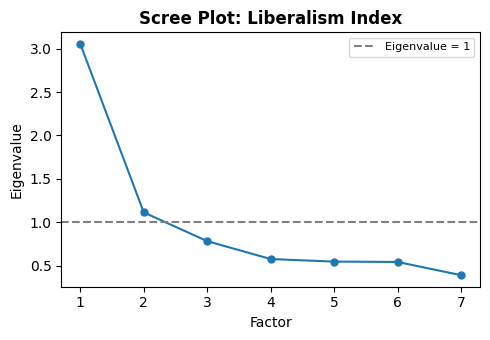

In [12]:
def get_screeplot(eigenvalues, title="Scree Plot"):
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.plot(range(1, len(eigenvalues) + 1), eigenvalues, "o-", markersize=5)
    ax.axhline(y=1, linestyle="--", color="gray", label="Eigenvalue = 1")
    ax.set_xlabel("Factor")
    ax.set_ylabel("Eigenvalue")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(1, len(eigenvalues) + 1))
    ax.legend(fontsize=8)
    plt.tight_layout()
    return fig


fig_scree = get_screeplot(eigenvalues, "Scree Plot: Liberalism Index")
fig_scree.savefig(
    os.path.join(results_path, "Appendix/Index/screeplot_liberal.png"),
    dpi=300, bbox_inches="tight",
)
plt.show()

In [13]:
# ── Extract factor scores and rescale to [0, 1] ───────────────────────────────
df_items_for_scoring = df[liberal_items].astype(float)
valid_mask = df_items_for_scoring.notna().all(axis=1)

fa_scores = np.full(len(df), np.nan)
fa_scores[valid_mask.values] = fa.transform(df_items_for_scoring[valid_mask])[:, 0]

valid_scores = fa_scores[~np.isnan(fa_scores)]
score_min, score_max = valid_scores.min(), valid_scores.max()

df["liberal_index"] = np.where(
    ~np.isnan(fa_scores),
    (fa_scores - score_min) / (score_max - score_min),
    np.nan,
)

print(f"Liberal Index — non-missing: {df['liberal_index'].notna().sum():,}")
print(df["liberal_index"].describe().round(3))

Liberal Index — non-missing: 5,324
count    5324.000
mean        0.205
std         0.169
min         0.000
25%         0.067
50%         0.171
75%         0.308
max         1.000
Name: liberal_index, dtype: float64


---
## Section 5: Subgroup Definitions and Discontinuity Plots

We split the sample into the subgroups needed for H1–H3:

| Subgroup | Hypothesis |
|---|---|
| Full Sample | H1 — any effect of first-time voting |
| Independents | H2 — effect larger for non-partisans |
| Partisans (D + R combined) | H2 — effect smaller for partisans |
| Democrats | H3 — directional partisan heterogeneity |
| Republicans | H3 — directional partisan heterogeneity |

Discontinuity plots use **age at the 2012 election** on the x-axis (`age_in_2012 = age − 8`), with the vertical cutoff line at 18. The plot is restricted to respondents aged ≤ 30 in 2020 (≤ 22 in 2012) for a clean window around the cutoff.

In [14]:
df_democrats    = df[df["party_summary"] == "Democrat"].copy()
df_republicans  = df[df["party_summary"] == "Republican"].copy()
df_partisans    = df[df["party_summary"].isin(["Democrat", "Republican"])].copy()
df_independents = df[df["party_summary"] == "Independent"].copy()

for name, sub in [("Full", df), ("Democrats", df_democrats), ("Republicans", df_republicans),
                   ("Partisans", df_partisans), ("Independents", df_independents)]:
    print(f"{name:15s}: n={len(sub):,}")

Full           : n=5,441
Democrats      : n=1,860
Republicans    : n=1,645
Partisans      : n=3,505
Independents   : n=1,228


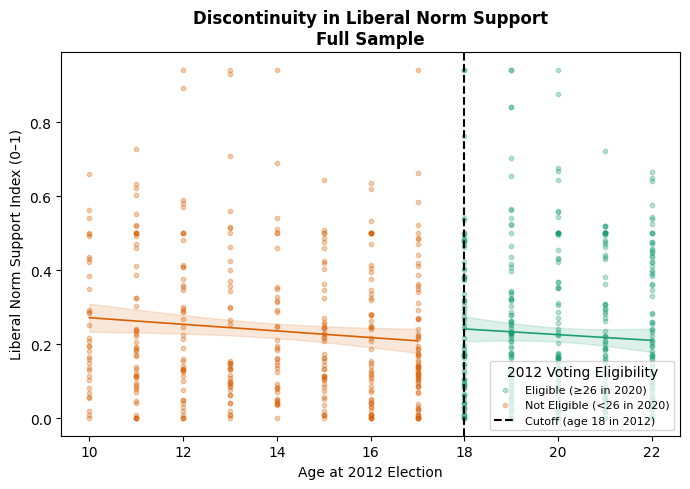

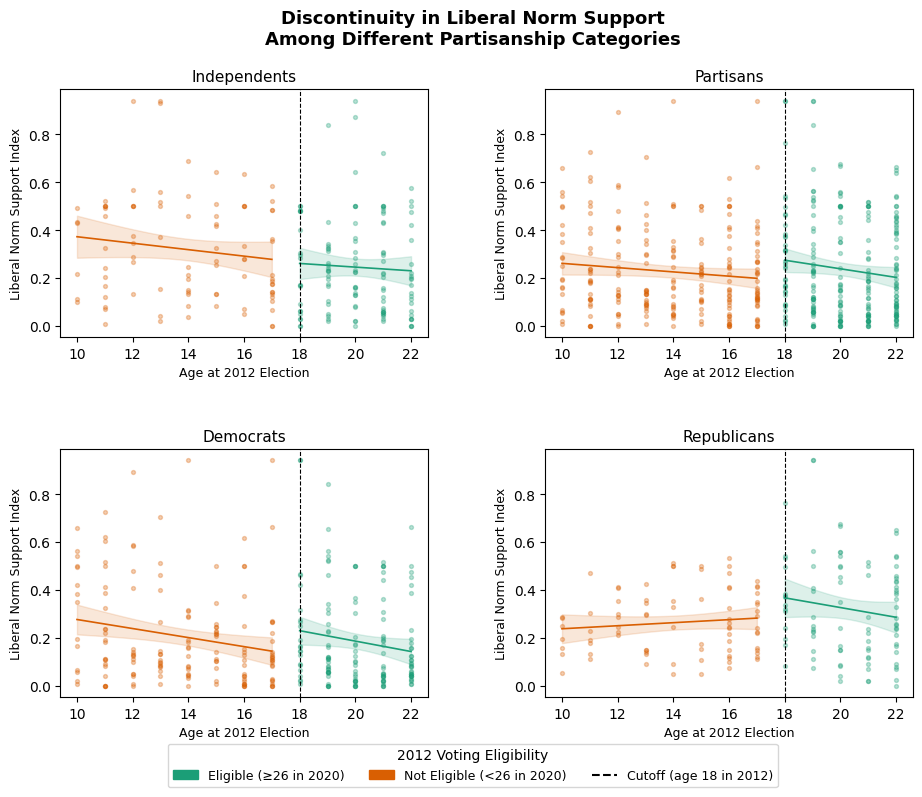

In [15]:
def get_discontinuityplot(
    dataframe,
    outcome="liberal_index",
    outcome_name="Liberal Norm Support",
    party_id="party_summary",
):
    """
    Returns {'plot_all': fig, 'plot_subgroups': fig}.
    X-axis: age_in_2012 (age at the 2012 election).
    Cutoff shown at age 18 in 2012 (= age 26 in 2020 = years_from_cutoff 0).
    Restricted to age <= 30 in 2020 (= age <= 22 in 2012).
    """
    df_plot = dataframe[~dataframe[party_id].isna()].copy()
    df_plot = df_plot[df_plot["age"] <= 30]

    party_label_map = {
        "Democrat": "Democrats",
        "Republican": "Republicans",
        "Independent": "Independents",
    }
    df_plot["subgroup"] = df_plot[party_id].map(party_label_map)

    df_part = df_plot[df_plot["subgroup"].isin(["Democrats", "Republicans"])].copy()
    df_part["subgroup"] = "Partisans"
    df_combined = pd.concat([df_plot, df_part], ignore_index=True)

    subgroup_order = ["Independents", "Partisans", "Democrats", "Republicans"]
    df_combined = df_combined[
        df_combined[outcome].notna() & df_combined["subgroup"].notna()
    ]
    df_combined["subgroup"] = pd.Categorical(
        df_combined["subgroup"], categories=subgroup_order, ordered=True
    )

    colors = {0: "#1b9e77", 1: "#d95f02"}

    def fit_line_with_ci(ax, group, outcome, color, lw=1.2, ci_alpha=0.15):
        xv = group["age_in_2012"].values
        yv = group[outcome].values
        mask = ~(np.isnan(xv) | np.isnan(yv))
        xm, ym = xv[mask], yv[mask]
        n = len(xm)
        if n < 4:
            return
        slope, intercept, *_ = stats.linregress(xm, ym)
        x_range = np.linspace(xm.min(), xm.max(), 200)
        y_fit = intercept + slope * x_range
        resid_se = np.sqrt(np.sum((ym - (intercept + slope * xm)) ** 2) / (n - 2))
        se_fit = resid_se * np.sqrt(
            1 / n + (x_range - xm.mean()) ** 2 / np.sum((xm - xm.mean()) ** 2)
        )
        t_crit = stats.t.ppf(0.975, df=n - 2)
        ax.plot(x_range, y_fit, color=color, linewidth=lw)
        ax.fill_between(
            x_range,
            y_fit - t_crit * se_fit,
            y_fit + t_crit * se_fit,
            alpha=ci_alpha,
            color=color,
        )

    # ── Full-sample plot ──────────────────────────────────────────────────────
    full_valid = dataframe[dataframe[outcome].notna() & (dataframe["age"] <= 30)]
    fig_all, ax_all = plt.subplots(figsize=(7, 5))
    for treat_val, group in full_valid.groupby("treatment"):
        label = "Eligible (≥26 in 2020)" if treat_val == 0 else "Not Eligible (<26 in 2020)"
        ax_all.scatter(
            group["age_in_2012"], group[outcome],
            alpha=0.3, s=10, color=colors[treat_val], label=label,
        )
        fit_line_with_ci(ax_all, group, outcome, color=colors[treat_val])
    ax_all.axvline(x=18, linestyle="--", color="black", label="Cutoff (age 18 in 2012)")
    ax_all.set_xlabel("Age at 2012 Election")
    ax_all.set_ylabel(f"{outcome_name} Index (0–1)")
    ax_all.set_title(f"Discontinuity in {outcome_name}\nFull Sample", fontweight="bold")
    ax_all.legend(title="2012 Voting Eligibility", loc="lower right", fontsize=8)
    plt.tight_layout()

    # ── Subgroup plot (2×2) ───────────────────────────────────────────────────
    fig_sub, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.flatten()
    for idx, sg in enumerate(subgroup_order):
        ax = axes[idx]
        sub_data = df_combined[df_combined["subgroup"] == sg]
        for treat_val, group in sub_data.groupby("treatment"):
            ax.scatter(
                group["age_in_2012"], group[outcome],
                alpha=0.3, s=8, color=colors[treat_val],
            )
            fit_line_with_ci(ax, group, outcome, color=colors[treat_val])
        ax.axvline(x=18, linestyle="--", color="black", linewidth=0.8)
        ax.set_title(sg, fontsize=11)
        ax.set_xlabel("Age at 2012 Election", fontsize=9)
        ax.set_ylabel(f"{outcome_name} Index", fontsize=9)

    handles = [
        mpatches.Patch(color=colors[0], label="Eligible (≥26 in 2020)"),
        mpatches.Patch(color=colors[1], label="Not Eligible (<26 in 2020)"),
        plt.Line2D([0], [0], linestyle="--", color="black", label="Cutoff (age 18 in 2012)"),
    ]
    fig_sub.legend(
        handles=handles,
        title="2012 Voting Eligibility",
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.0),
        fontsize=9,
    )
    fig_sub.suptitle(
        f"Discontinuity in {outcome_name}\nAmong Different Partisanship Categories",
        fontweight="bold",
        fontsize=13,
    )
    fig_sub.subplots_adjust(top=0.88, bottom=0.12, hspace=0.45, wspace=0.32)

    return {"plot_all": fig_all, "plot_subgroups": fig_sub}


disc_plots = get_discontinuityplot(df)
disc_plots["plot_all"].savefig(
    os.path.join(results_path, "Main/Plots/Discontinuity/discontinuityplot_full.png"),
    dpi=300, bbox_inches="tight",
)
disc_plots["plot_subgroups"].savefig(
    os.path.join(results_path, "Main/Plots/Discontinuity/discontinuityplot_subgroups.png"),
    dpi=300, bbox_inches="tight",
)
plt.show()


---
## Section 6: Covariate Balance and Control Selection

We test whether potential control variables are **imbalanced** across the treatment and control groups:
- **Continuous** variables (>5 unique values): two-sample t-test, p < 0.30 = imbalanced
- **Categorical** variables: chi-squared test, p < 0.05 = imbalanced

Only imbalanced covariates are included. `race` is converted to dummies with **White** as the omitted baseline.

In [16]:
def get_imbalanced_controls(data, potential_controls, thr_num=0.3, thr_cat=0.05):
    imbalanced = []
    for var in potential_controls:
        if pd.api.types.is_numeric_dtype(data[var]) and data[var].nunique() > 5:
            g0 = data.loc[data["treatment"] == 0, var].dropna()
            g1 = data.loc[data["treatment"] == 1, var].dropna()
            _, pval = ttest_ind(g0, g1)
            threshold = thr_num
        else:
            ct = pd.crosstab(data[var].fillna("Missing"), data["treatment"])
            _, pval, _, _ = chi2_contingency(ct)
            threshold = thr_cat

        tag = "IMBALANCED" if pval < threshold else "balanced"
        print(f"  {var:30s}: {tag:12s} (p={pval:.3f})")
        if pval < threshold:
            imbalanced.append(var)
    return imbalanced


potential_controls = ["education", "sex", "income", "race"]
print("Covariate balance tests:")
imbalanced_controls = get_imbalanced_controls(df, potential_controls)

Covariate balance tests:
  education                     : IMBALANCED   (p=0.000)
  sex                           : balanced     (p=0.074)
  income                        : IMBALANCED   (p=0.000)
  race                          : IMBALANCED   (p=0.000)


In [17]:
def add_race_dummies(data):
    """Add race indicator columns, dropping race_White as the baseline."""
    dummies = pd.get_dummies(data["race"], prefix="race", drop_first=False)
    if "race_White" in dummies.columns:
        dummies = dummies.drop(columns=["race_White"])
    return pd.concat([data, dummies.astype(float)], axis=1)


df             = add_race_dummies(df)
df_democrats   = add_race_dummies(df_democrats)
df_republicans = add_race_dummies(df_republicans)
df_independents = add_race_dummies(df_independents)
df_partisans   = add_race_dummies(df_partisans)

race_dummies = ["race_Black", "race_Hispanic", "race_Asian", "race_Native", "race_Other"]
controls = [c for c in imbalanced_controls if c != "race"] + race_dummies
print(f"\nFinal control variables: {controls}")


Final control variables: ['education', 'income', 'race_Black', 'race_Hispanic', 'race_Asian', 'race_Native', 'race_Other']


---
## Section 7: RDD Analysis — Helper Functions

- **`extract_rdd_summary()`** — turns an `rdrobust` result into a tidy DataFrame (one row per estimate type). Preferred estimate for the main text: **Bias-Corrected**.
- **`run_rdd_models()`** — runs two models per sample (with/without controls).

> **Running variable & cutoff:** `years_from_cutoff = 26 − age`, `c = 0`. Bandwidth expressed in **years**. MSE-optimal selection (`mserd`) used throughout.

In [18]:
def pull_estimates(r):
    """Extract point estimates, SEs, and p-values from an rdrobust result."""
    coef = np.asarray(r.coef).flatten()
    se   = np.asarray(r.se).flatten()
    pv   = np.asarray(r.pv).flatten()
    return {
        "coef_conv": float(coef[0]), "se_conv": float(se[0]), "pv_conv": float(pv[0]),
        "coef_bc":   float(coef[1]), "se_bc":   float(se[1]), "pv_bc":   float(pv[1]),
        "coef_rob":  float(coef[2]), "se_rob":  float(se[2]), "pv_rob":  float(pv[2]),
    }


def extract_rdd_summary(rd_object, model_label="Model"):
    est = pull_estimates(rd_object)
    bwselect = getattr(rd_object, "bwselect", "mserd")
    bw_type = "MSE-optimal" if bwselect == "mserd" else bwselect
    bw_h = round(float(np.asarray(rd_object.bws).flatten()[0]), 2)
    n_h  = int(rd_object.N_h[0]) + int(rd_object.N_h[1])

    rows = []
    for est_type, ck, sk, pk in [
        ("Conventional",              "coef_conv", "se_conv", "pv_conv"),
        ("Bias-Corrected",             "coef_bc",   "se_bc",   "pv_bc"),
        ("Bias-Corrected (Robust SE)", "coef_rob",  "se_rob",  "pv_rob"),
    ]:
        rows.append({
            "Model":          model_label,
            "Estimate Type":  est_type,
            "Estimate":       round(est[ck], 3),
            "SE":             round(est[sk], 3),
            "P-Value":        round(est[pk], 3),
            "Bandwidth Type": bw_type,
            "Bandwidth (h)":  bw_h,
            "N":              n_h,
        })
    return pd.DataFrame(rows)


def _prep_arrays(data, index_var, controls):
    """Return aligned (y, x, covs_df) with fully valid y and x rows.
    Running variable x = years_from_cutoff = 26 - age.
    """
    y = data[index_var].values.astype(float)
    x = data["years_from_cutoff"].values.astype(float)
    valid = ~(np.isnan(y) | np.isnan(x))
    y, x = y[valid], x[valid]
    covs_df = data[controls].iloc[np.where(valid)[0]].astype(float)
    return y, x, covs_df


def run_rdd_models(data, index_var, controls, sample_label):
    y, x, covs_df = _prep_arrays(data, index_var, controls)

    rdd_simple = rdrobust(y=y, x=x, c=0, all=True)
    summary_simple = extract_rdd_summary(rdd_simple, "Without Controls")

    valid2   = covs_df.notna().all(axis=1).values
    y2, x2   = y[valid2], x[valid2]
    covs_arr = covs_df.iloc[np.where(valid2)[0]].values
    rdd_controls = rdrobust(y=y2, x=x2, c=0, covs=covs_arr, all=True)
    summary_controls = extract_rdd_summary(rdd_controls, "With Controls")

    result = pd.concat([summary_simple, summary_controls], ignore_index=True)
    result.insert(0, "Sample", sample_label)
    return result


print("Helper functions defined.")

Helper functions defined.


---
## Section 8: Run RDD Models

In [19]:
# ── H1: Full sample ───────────────────────────────────────────────────────────
print("Running: Full Sample...")
rdd_liberal_full = run_rdd_models(df, "liberal_index", controls, "Full Sample")

# ── H2: Independents vs. Partisans ────────────────────────────────────────────
print("Running: Independents...")
rdd_liberal_independents = run_rdd_models(df_independents, "liberal_index", controls, "Independents")
print("Running: Partisans...")
rdd_liberal_partisans = run_rdd_models(df_partisans, "liberal_index", controls, "Partisans")

# ── H3: Democrats vs. Republicans ─────────────────────────────────────────────
print("Running: Democrats...")
rdd_liberal_democrats = run_rdd_models(df_democrats, "liberal_index", controls, "Democrats")
print("Running: Republicans...")
rdd_liberal_republicans = run_rdd_models(df_republicans, "liberal_index", controls, "Republicans")

print("Done.")

Running: Full Sample...
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Running: Independents...
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Running: Partisans...
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Running: Democrats...
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Running: Republicans...
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass poin

In [20]:
sample_order = ["Republicans", "Democrats", "Partisans", "Independents", "Full Sample"]

rdd_liberal = pd.concat(
    [rdd_liberal_full, rdd_liberal_independents, rdd_liberal_partisans,
     rdd_liberal_democrats, rdd_liberal_republicans],
    ignore_index=True,
)
rdd_liberal["Outcome"] = "Liberal Attitudes"
rdd_liberal["Sample"] = pd.Categorical(
    rdd_liberal["Sample"], categories=sample_order, ordered=True
)

rdd_liberal.to_csv(os.path.join(results_path, "Main/rdd_liberal.csv"), index=False)

# Display bias-corrected estimates
rdd_liberal[rdd_liberal["Estimate Type"] == "Bias-Corrected"].sort_values("Sample")

,Sample,Model,Estimate Type,Estimate,SE,P-Value,Bandwidth Type,Bandwidth (h),N,Outcome
25,Republicans,Without Controls,Bias-Corrected,-0.076,0.074,0.299,MSE-optimal,6.30,198,Liberal Attitudes
28,Republicans,With Controls,Bias-Corrected,-0.102,0.075,0.176,MSE-optimal,5.79,162,Liberal Attitudes
19,Democrats,Without Controls,Bias-Corrected,0.011,0.045,0.807,MSE-optimal,9.15,438,Liberal Attitudes
22,Democrats,With Controls,Bias-Corrected,0.051,0.038,0.185,MSE-optimal,9.62,431,Liberal Attitudes
13,Partisans,Without Controls,Bias-Corrected,0.007,0.038,0.862,MSE-optimal,8.20,671,Liberal Attitudes
16,Partisans,With Controls,Bias-Corrected,0.023,0.034,0.505,MSE-optimal,8.40,659,Liberal Attitudes
7,Independents,Without Controls,Bias-Corrected,-0.019,0.047,0.680,MSE-optimal,8.33,285,Liberal Attitudes
10,Independents,With Controls,Bias-Corrected,-0.054,0.043,0.209,MSE-optimal,8.38,276,Liberal Attitudes
1,Full Sample,Without Controls,Bias-Corrected,-0.006,0.025,0.799,MSE-optimal,8.36,1157,Liberal Attitudes
4,Full Sample,With Controls,Bias-Corrected,0.001,0.023,0.977,MSE-optimal,8.52,1132,Liberal Attitudes


---
## Section 9: Coefficient Plots

Two plots:
1. **Main coefplot** — bias-corrected estimates only, with and without controls
2. **Robustness coefplot** — all three estimate types side-by-side

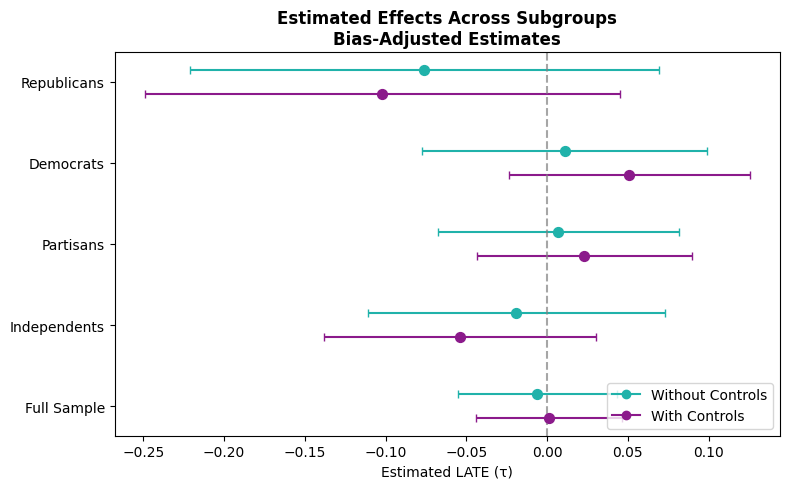

In [21]:
def get_coefplot(dataframe, title="Estimated Effects Across Subgroups",
                 subtitle="Bias-Adjusted Estimates"):
    colors  = {"Without Controls": "#20b2aa", "With Controls": "#8b1a8b"}
    offsets = {"Without Controls":  0.15,      "With Controls": -0.15}

    samples = list(reversed(list(dataframe["Sample"].cat.categories)))
    y_map   = {s: i for i, s in enumerate(samples)}

    fig, ax = plt.subplots(figsize=(8, 5))
    for model, group in dataframe.groupby("Model"):
        for _, row in group.iterrows():
            y = y_map[row["Sample"]] + offsets.get(model, 0)
            ax.scatter(row["Estimate"], y, color=colors.get(model, "blue"), s=50, zorder=5)
            ax.errorbar(row["Estimate"], y, xerr=1.96 * row["SE"],
                        fmt="none", color=colors.get(model, "blue"), linewidth=1.5, capsize=3)

    ax.axvline(x=0, linestyle="--", color="gray", alpha=0.7)
    ax.set_yticks(list(y_map.values()))
    ax.set_yticklabels(list(y_map.keys()))
    ax.set_xlabel("Estimated LATE (\u03c4)")
    ax.set_title(f"{title}\n{subtitle}", fontweight="bold")
    handles = [mlines.Line2D([], [], color=colors[m], marker="o", linestyle="-", label=m)
               for m in ["Without Controls", "With Controls"]]
    ax.legend(handles=handles, loc="lower right")
    plt.tight_layout()
    return fig


rdd_bc = rdd_liberal[rdd_liberal["Estimate Type"] == "Bias-Corrected"].copy()
rdd_bc["Model"] = pd.Categorical(
    rdd_bc["Model"], categories=["Without Controls", "With Controls"], ordered=True)
rdd_bc["Sample"] = pd.Categorical(
    rdd_bc["Sample"], categories=sample_order, ordered=True)

fig_coef = get_coefplot(rdd_bc)
fig_coef.savefig(os.path.join(results_path, "Main/Plots/coefplot_liberal.png"),
                 dpi=300, bbox_inches="tight")
plt.show()

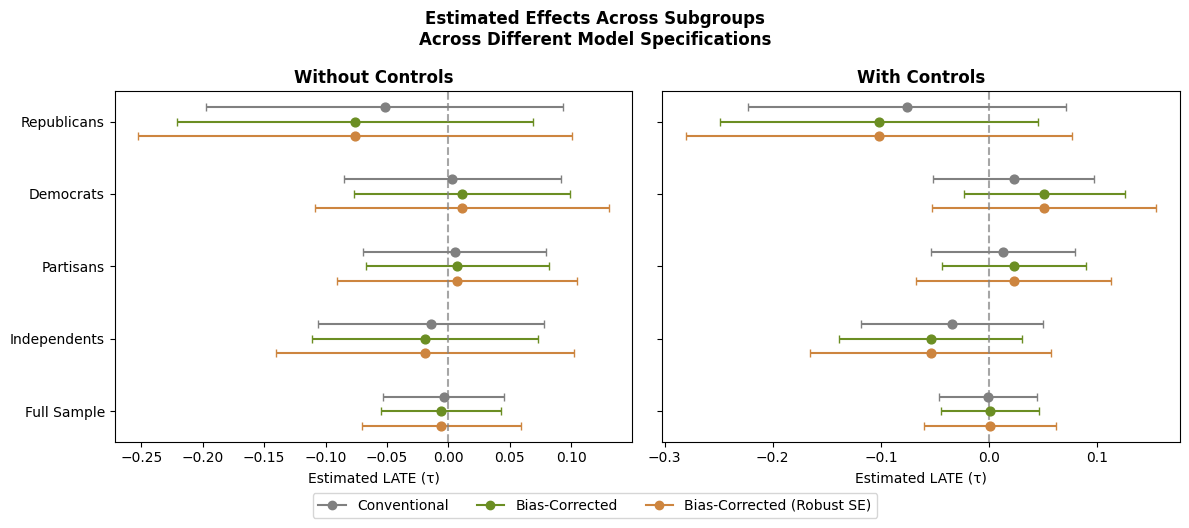

In [22]:
def get_coefplot_robustness(dataframe, title="Estimated Effects Across Subgroups",
                             subtitle="Across Different Model Specifications"):
    colors = {"Conventional": "gray", "Bias-Corrected": "olivedrab",
              "Bias-Corrected (Robust SE)": "#cd853f"}
    offsets = {"Conventional": 0.2, "Bias-Corrected": 0.0, "Bias-Corrected (Robust SE)": -0.2}

    models  = list(dataframe["Model"].unique())
    samples = list(reversed(list(dataframe["Sample"].cat.categories)))
    y_map   = {s: i for i, s in enumerate(samples)}

    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), sharey=True)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        for est_type, group in dataframe[dataframe["Model"] == model].groupby("Estimate Type"):
            for _, row in group.iterrows():
                y = y_map[row["Sample"]] + offsets.get(est_type, 0)
                ax.scatter(row["Estimate"], y, color=colors.get(est_type, "blue"), s=40, zorder=5)
                ax.errorbar(row["Estimate"], y, xerr=1.96 * row["SE"],
                            fmt="none", color=colors.get(est_type, "blue"), linewidth=1.5, capsize=3)
        ax.axvline(x=0, linestyle="--", color="gray", alpha=0.7)
        ax.set_yticks(list(y_map.values()))
        ax.set_yticklabels(list(y_map.keys()))
        ax.set_xlabel("Estimated LATE (\u03c4)")
        ax.set_title(model, fontweight="bold")

    handles = [mlines.Line2D([], [], color=colors[e], marker="o", linestyle="-", label=e)
               for e in colors]
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle(f"{title}\n{subtitle}", fontweight="bold")
    plt.tight_layout()
    return fig


rdd_all_types = rdd_liberal.copy()
rdd_all_types["Estimate Type"] = pd.Categorical(
    rdd_all_types["Estimate Type"],
    categories=["Conventional", "Bias-Corrected", "Bias-Corrected (Robust SE)"], ordered=True)
rdd_all_types["Sample"] = pd.Categorical(
    rdd_all_types["Sample"], categories=sample_order, ordered=True)

fig_coef_rob = get_coefplot_robustness(rdd_all_types)
fig_coef_rob.savefig(os.path.join(results_path, "Main/Plots/coefplot_robustness.png"),
                     dpi=300, bbox_inches="tight")
plt.show()

---
## Section 10: Robustness Checks

Three families of checks for each subgroup:

1. **Bandwidth sensitivity** — 30%–200% of MSE-optimal bandwidth in **years**. Estimates should be stable.
2. **Placebo cutoffs** — RDD re-run at −3, −2, −1, 0, +1, +2, +3 **years** from the true cutoff. Only the true cutoff (0) should yield a significant result.
3. **Polynomial degree** — 1st, 2nd, 3rd order. Results should be robust.

All checks run with and without controls.

In [23]:
def run_robustness_checks(data, index_var, controls, sample_label):
    """
    Robustness checks with years_from_cutoff as running variable (c = 0).
    Bandwidths and placebo cutoffs are in years.
    """
    y, x, covs_df = _prep_arrays(data, index_var, controls)

    valid_covs = covs_df.notna().all(axis=1).values
    y_c, x_c   = y[valid_covs], x[valid_covs]
    covs_c     = covs_df.iloc[np.where(valid_covs)[0]].values
    h_opt      = float(np.asarray(rdrobust(y=y_c, x=x_c, c=0, covs=covs_c).bws).flatten()[0])

    all_rows = []

    # ── Bandwidth sensitivity (in years) ──────────────────────────────────────
    bws = np.unique(np.round(np.linspace(h_opt * 0.3, h_opt * 2.0, 20), 2))
    for use_covs in [False, True]:
        yy, xx, cc = (y_c, x_c, covs_c) if use_covs else (y, x, None)
        for h in bws:
            try:
                r = rdrobust(y=yy, x=xx, c=0, h=float(h), covs=cc, all=True)
                row = pull_estimates(r)
                row.update({"bandwidth": h, "controls": use_covs,
                             "h_opt": h_opt, "check_type": "bandwidth",
                             "sample": sample_label})
                all_rows.append(row)
            except Exception:
                pass

    # ── Placebo cutoffs (±1, ±2, ±3 years) ───────────────────────────────────
    placebo_cutoffs = [-3, -2, -1, 0, 1, 2, 3]
    for use_covs in [False, True]:
        yy, xx, cc = (y_c, x_c, covs_c) if use_covs else (y, x, None)
        for co in placebo_cutoffs:
            try:
                r = rdrobust(y=yy, x=xx, c=co, covs=cc, all=True)
                row = pull_estimates(r)
                row.update({"cutoff": co, "controls": use_covs,
                             "check_type": "cutoffs", "sample": sample_label})
                all_rows.append(row)
            except Exception:
                pass

    # ── Polynomial degree ─────────────────────────────────────────────────────
    for use_covs in [False, True]:
        yy, xx, cc = (y_c, x_c, covs_c) if use_covs else (y, x, None)
        for p in [1, 2, 3]:
            try:
                r = rdrobust(y=yy, x=xx, c=0, p=p, covs=cc, all=True)
                row = pull_estimates(r)
                row.update({"polynomial": p, "controls": use_covs,
                             "check_type": "polynomial", "sample": sample_label})
                all_rows.append(row)
            except Exception:
                pass

    return pd.DataFrame(all_rows)


print("Robustness check function defined.")

Robustness check function defined.


In [24]:
robustness_subgroups = [
    (df,              "Full Sample"),
    (df_independents, "Independents"),
    (df_partisans,    "Partisans"),
    (df_democrats,    "Democrats"),
    (df_republicans,  "Republicans"),
]

all_robustness_dfs = []
for data, label in robustness_subgroups:
    print(f"  Robustness checks: {label}")
    rob = run_robustness_checks(data, "liberal_index", controls, label)
    all_robustness_dfs.append(rob)

all_robustness = pd.concat(all_robustness_dfs, ignore_index=True)
all_robustness.to_csv(
    os.path.join(results_path, "Appendix/Robustness Checks/all_robustness_checks.csv"),
    index=False,
)
print(f"\nTotal robustness rows saved: {len(all_robustness):,}")

  Robustness checks: Full Sample
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
Mass points detected in the running variable.
M

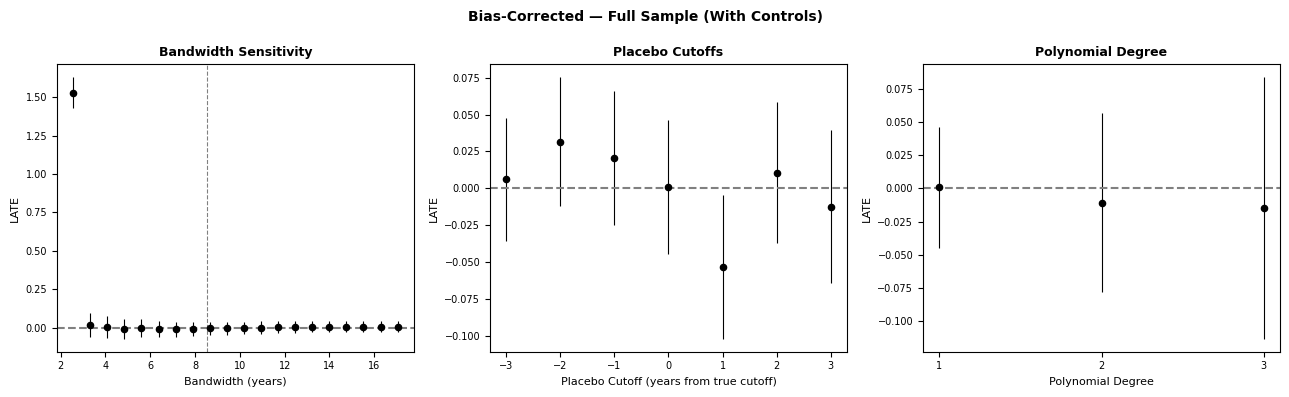

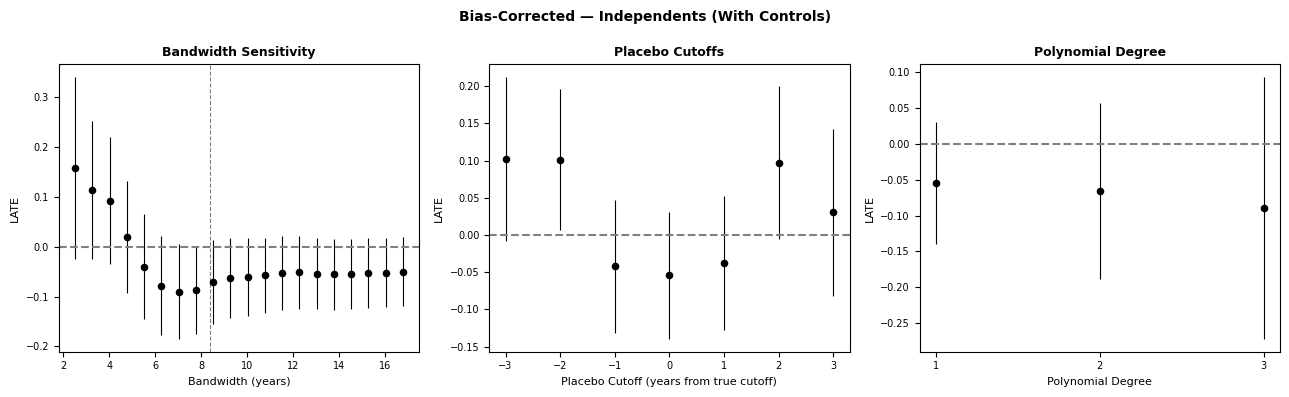

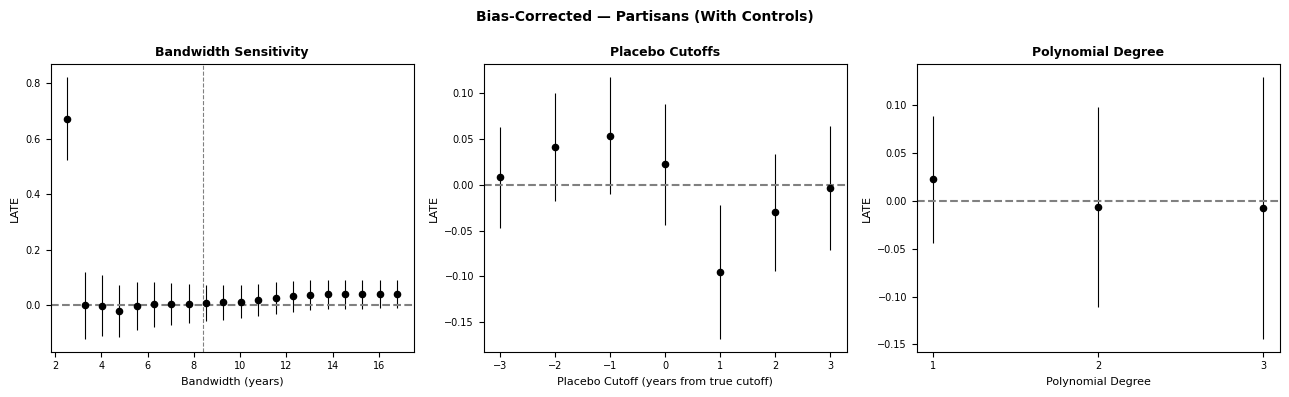

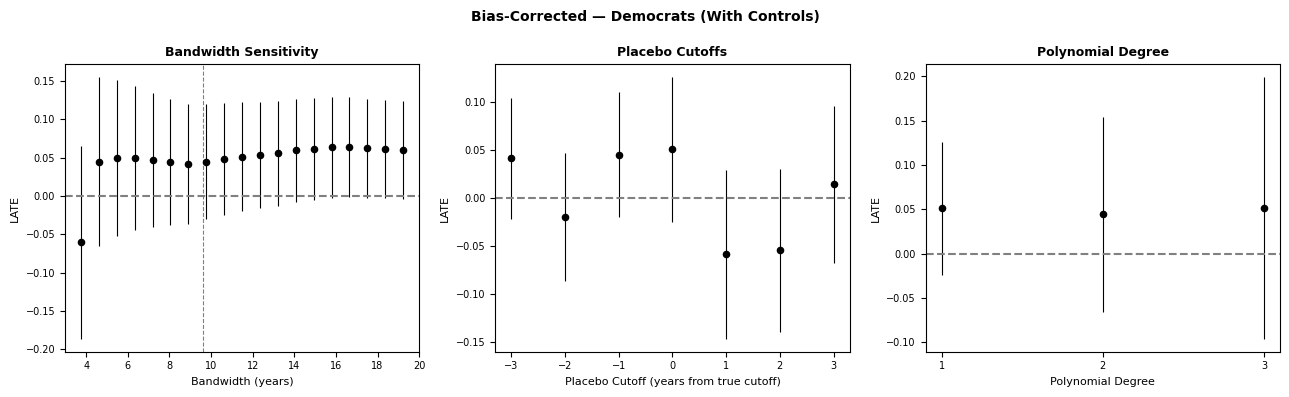

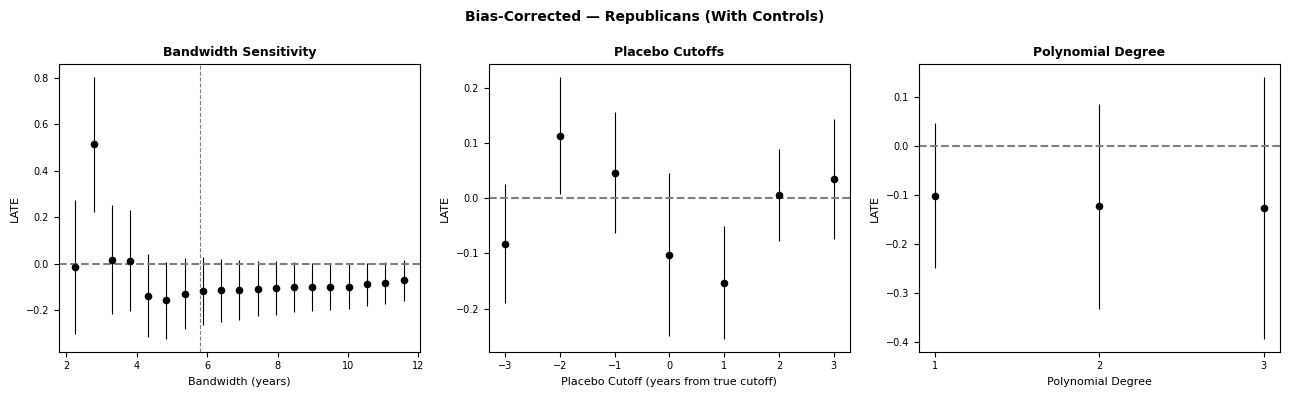

In [25]:
def get_robustnessplots(data, subgroup_name, estimate_type=3, include_covariates=True):
    """
    Three-panel robustness figure.
    estimate_type: 1=Conventional, 2=Bias-Corrected, 3=BC+Robust SE (preferred)
    """
    cols = {
        1: ("coef_conv", "se_conv", "Conventional"),
        2: ("coef_bc",   "se_bc",   "Bias-Corrected"),
        3: ("coef_rob",  "se_rob",  "Bias-Corrected (Robust SE)"),
    }
    coef_col, se_col, est_name = cols[estimate_type]
    ctrl_label = "(With Controls)" if include_covariates else "(Without Controls)"

    def prep(check_type):
        return data[
            (data["check_type"] == check_type)
            & (data["sample"] == subgroup_name)
            & (data["controls"] == include_covariates)
        ].copy()

    bw_plot   = prep("bandwidth")
    co_plot   = prep("cutoffs")
    poly_plot = prep("polynomial")

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    def make_panel(ax, df_panel, x_var, xlabel, title):
        if df_panel.empty:
            ax.set_title(title, fontsize=9)
            return
        ax.scatter(df_panel[x_var], df_panel[coef_col], color="black", s=20, zorder=5)
        ax.errorbar(df_panel[x_var], df_panel[coef_col], yerr=1.96 * df_panel[se_col],
                    fmt="none", color="black", linewidth=0.8, capsize=0)
        ax.axhline(y=0, linestyle="--", color="gray")
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel("LATE", fontsize=8)
        ax.set_title(title, fontweight="bold", fontsize=9)
        ax.tick_params(labelsize=7)

    h_opt_val = bw_plot["h_opt"].iloc[0] if not bw_plot.empty else None
    make_panel(axes[0], bw_plot,   "bandwidth",  "Bandwidth (years)", "Bandwidth Sensitivity")
    if h_opt_val:
        axes[0].axvline(x=h_opt_val, linestyle="--", color="gray", linewidth=0.8)

    make_panel(axes[1], co_plot, "cutoff",
               "Placebo Cutoff (years from true cutoff)", "Placebo Cutoffs")
    if not co_plot.empty:
        axes[1].set_xticks([-3, -2, -1, 0, 1, 2, 3])

    make_panel(axes[2], poly_plot, "polynomial", "Polynomial Degree", "Polynomial Degree")
    if not poly_plot.empty:
        axes[2].set_xticks([1, 2, 3])

    fig.suptitle(f"{est_name} — {subgroup_name} {ctrl_label}", fontweight="bold", fontsize=10)
    plt.tight_layout()
    return fig


subgroup_strings = ["Full Sample", "Independents", "Partisans", "Democrats", "Republicans"]

for sg in subgroup_strings:
    fig_rob = get_robustnessplots(all_robustness, sg, estimate_type=2, include_covariates=True)
    fig_rob.savefig(
        os.path.join(results_path,
                     f"Appendix/Robustness Checks/robustness_{sg.replace(' ', '_')}.png"),
        dpi=300, bbox_inches="tight",
    )
    plt.show()

---
## Summary of Outputs

| File | Location |
|---|---|
| `fa_alpha_summary.csv` | `Results/Appendix/Index/` |
| `fa_diagnostics.csv` | `Results/Appendix/Index/` |
| `fa_eigenvalues.csv` | `Results/Appendix/Index/` |
| `screeplot_liberal.png` | `Results/Appendix/Index/` |
| `discontinuityplot_full.png` | `Results/Main/Plots/Discontinuity/` |
| `discontinuityplot_subgroups.png` | `Results/Main/Plots/Discontinuity/` |
| `rdd_liberal.csv` | `Results/Main/` |
| `coefplot_liberal.png` | `Results/Main/Plots/` |
| `coefplot_robustness.png` | `Results/Main/Plots/` |
| `all_robustness_checks.csv` | `Results/Appendix/Robustness Checks/` |
| `robustness_<subgroup>.png` (×5) | `Results/Appendix/Robustness Checks/` |